In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import UGate, iSwapGate, CXGate
from qiskit.quantum_info import Operator
from tqdm import tqdm

from gulps.core.invariants import GateInvariants
from gulps.core.isa import DiscreteISA
from gulps.core.coverage import coverage_report
from gulps.viz.polytope_viz import _plot_polytope, COLORS as DEPTH_COLORS
from gulps.viz.weyl_chamber import WeylChamber

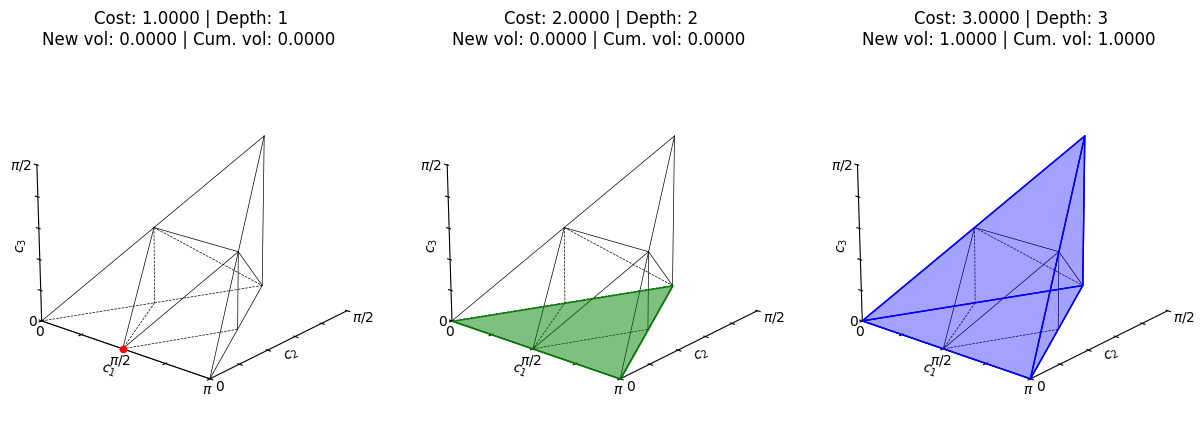

Coverage Set Statistics (Haar-averaged over SU(4))
Expected Cost:  3.000000
  Average cost per random 2-qubit unitary

Expected Depth: 3.000000
  Average number of 2-qubit gates


{'volume_info': [(1.0000000199999999, 1, 0, 0.0),
  (2.00000003, 2, 0, 0.0),
  (3.0000000399999998,
   3,
   np.float64(1.0000000000000002),
   np.float64(1.0000000000000002))],
 'expected_cost': np.float64(3.0000000400000006),
 'expected_depth': np.float64(3.000000000000001),
 'expected_index': np.float64(2.0000000000000004),
 'total_coverage': np.float64(1.0000000000000002)}

In [2]:
# --- Config ---
basis_gate = CXGate()
basis_power = 1.0

cost_2q = 1.0
cost_1q = 0.2  # 2-pulse SQ cost; 1-pulse is half

isa = DiscreteISA(
    gate_set=[basis_gate.power(basis_power)],
    costs=[basis_power],
    precompute_polytopes=True,
)
coverage_report(isa.coverage_set)

In [3]:
# --- Helpers ---


def make_ansatz(depth, sq_pulse_config):
    """Build ansatz: n 2Q gates with (n-1) interior SQ layers.

    sq_pulse_config: tuple of length (depth-1).
        1 = UGate(π/2,φ,λ), 1 real pulse, 2 params
        2 = UGate(θ,φ,λ),   2 real pulses, 3 params
    """
    assert len(sq_pulse_config) == depth - 1
    num_params = sum(2 * (p + 1) for p in sq_pulse_config)
    p = ParameterVector("p", num_params)
    qc = QuantumCircuit(2)
    k = 0
    for i in range(depth):
        qc.append(basis_gate.power(basis_power), [0, 1])
        if i < depth - 1:
            sq = sq_pulse_config[i]
            for qubit in [0, 1]:
                if sq == 1:
                    qc.append(UGate(np.pi / 2, p[k], p[k + 1]), [qubit])
                    k += 2
                else:
                    qc.append(UGate(p[k], p[k + 1], p[k + 2]), [qubit])
                    k += 3
    return qc, num_params


def sample_ansatz(depth, sq_pulse_config, n_samples=2048):
    qc, n_params = make_ansatz(depth, sq_pulse_config)
    label = ",".join(str(s) for s in sq_pulse_config)
    pts = []
    for _ in tqdm(range(n_samples), desc=f"d={depth} sq=({label})", leave=False):
        p = np.random.uniform(-np.pi, np.pi, n_params)
        bound = qc.assign_parameters(dict(zip(qc.parameters, p)))
        pts.append(np.abs(GateInvariants.from_unitary(Operator(bound)).weyl))
    return np.array(pts)


def sq_configs(depth):
    """Enumerate by number of 2-pulse layers: (1,1), (1,2), (2,2), ..."""
    n = depth - 1
    return [tuple([1] * (n - k) + [2] * k) for k in range(n + 1)]


def ansatz_cost(depth, sq_pulse_config):
    interior = sum(cost_1q if p == 2 else cost_1q / 2 for p in sq_pulse_config)
    exterior = 2 * cost_1q  # leading + trailing full SQ, always present
    return depth * cost_2q + interior + exterior

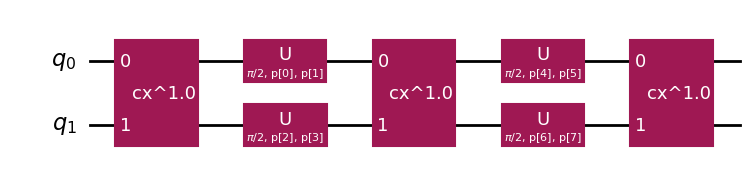

In [4]:
# --- Example ansatze ---
make_ansatz(3, (1, 1))[0].draw("mpl")

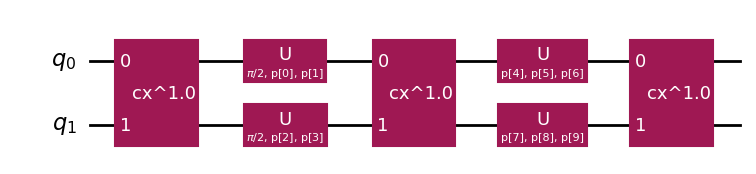

In [5]:
make_ansatz(3, (1, 2))[0].draw("mpl")

/tmp/ipykernel_3425397/482120669.py:58: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


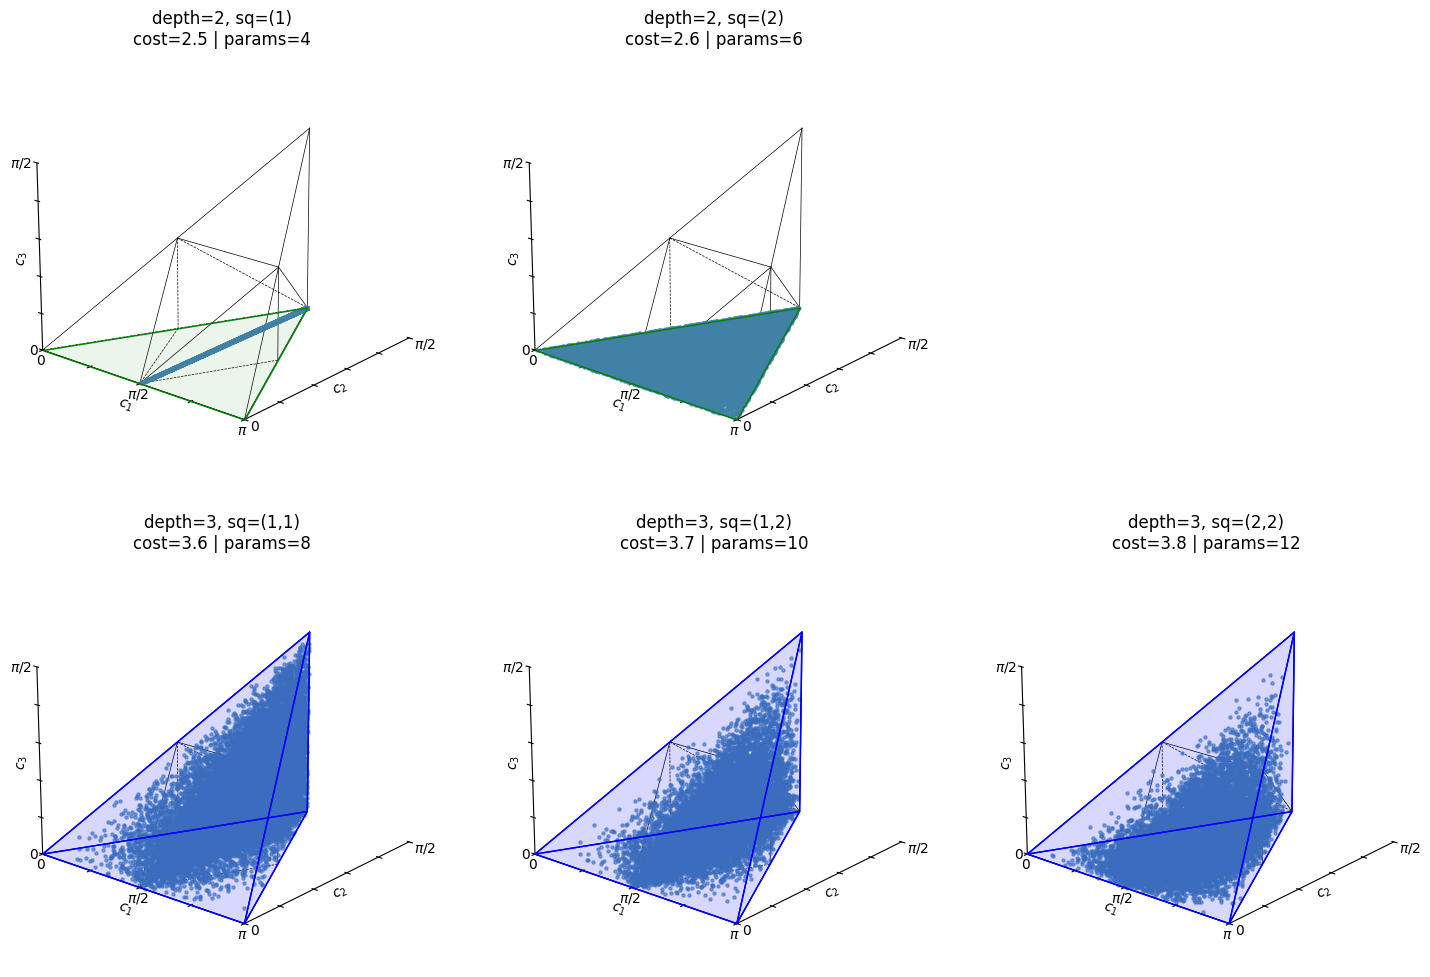

In [ ]:
# --- Experiment: sample ansatze ordered by cost ---
nontrivial = [p for p in isa.coverage_set if len(p.operations) > 0]
polytope_color = {
    id(p): DEPTH_COLORS[i % len(DEPTH_COLORS)] for i, p in enumerate(nontrivial)
}
depths = sorted({len(p.operations) for p in nontrivial if len(p.operations) >= 2})
max_cols = max(len(sq_configs(d)) for d in depths)

fig, axes = plt.subplots(
    len(depths),
    max_cols,
    subplot_kw={"projection": "3d"},
    figsize=(6 * max_cols, 6 * len(depths)),
    squeeze=False,
)

for row, d in enumerate(depths):
    configs = sq_configs(d)
    for col in range(max_cols):
        ax = axes[row, col]
        if col >= len(configs):
            ax.set_visible(False)
            continue

        cfg = configs[col]
        ax.set_proj_type("persp")
        w = WeylChamber()
        w.labels = {}
        w.render(ax)

        for polytope in nontrivial:
            if len(polytope.operations) == d:
                _plot_polytope(
                    polytope,
                    ax,
                    w,
                    color=polytope_color[id(polytope)],
                    alpha=0.08,
                    edgecolor=polytope_color[id(polytope)],
                )

        pts = sample_ansatz(d, cfg, n_samples=2**14)
        ax.scatter(
            pts[:, 0],
            pts[:, 1],
            pts[:, 2],
            color="steelblue",
            alpha=0.6,
            s=5,
            zorder=5,
            depthshade=False,
        )
        label = ",".join(str(s) for s in cfg)
        cost = ansatz_cost(d, cfg)
        n_params = make_ansatz(d, cfg)[1]
        ax.set_title(f"depth={d}, sq=({label})\ncost={cost:.1f} | params={n_params}")

plt.show()